a

# Análise Exploratória (EDA) — Exoplanetas

Este notebook é o primeiro contato com o catálogo de exoplanetas confirmados do
[NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/). O objetivo **não** é
responder perguntas científicas ainda — é **conhecer os dados**: o que tem, o que falta, o que
parece estranho e que perguntas eles sugerem.

**Roteiro**

1. Visão geral da tabela
2. Dados ausentes — e por que eles *não* faltam por acaso
3. Estatística descritiva
4. Valores estranhos (outliers)
5. Variáveis de descoberta (método, ano, observatório)
6. Distribuições das variáveis numéricas
7. Relações entre variáveis
8. Conclusões e perguntas para os módulos

Rode as células **de cima para baixo**. Se ainda não baixou os dados, rode `python main.py`
na raiz do projeto.

## Dicionário de colunas

O `data_fetch.py` baixa 24 colunas do NASA Exoplanet Archive (tabela `ps`). Abaixo, o que cada
uma significa — referência rápida para consultar durante a EDA.

| Coluna | Significado | Unidade |
| --- | --- | --- |
| `pl_name` | Nome do planeta | texto |
| `hostname` | Nome da estrela hospedeira | texto |
| `pl_orbper` | Período orbital (tempo de uma volta completa) | dias |
| `pl_orbsmax` | Semi-eixo maior da órbita (distância média planeta-estrela) | UA |
| `pl_orbeccen` | Excentricidade da órbita (0 = círculo perfeito, mais perto de 1 = mais alongada) | adimensional |
| `pl_insol` | Fluxo de energia (insolação) recebido da estrela | em unidades da Terra (1 = o que a Terra recebe do Sol) |
| `pl_eqt` | Temperatura de equilíbrio do planeta | Kelvin |
| `pl_rade` | Raio do planeta | raios terrestres |
| `pl_bmasse` | Massa do planeta (best mass — vem de medição direta ou de msini) | massas terrestres |
| `pl_dens` | Densidade do planeta | g/cm³ |
| `pl_radeerr1` | Incerteza do raio, para cima | raios terrestres |
| `pl_radeerr2` | Incerteza do raio, para baixo | raios terrestres |
| `st_teff` | Temperatura efetiva (de superfície) da estrela | Kelvin |
| `st_rad` | Raio da estrela | raios solares |
| `st_mass` | Massa da estrela | massas solares |
| `st_lum` | Luminosidade da estrela | log10(luminosidade solar) |
| `st_met` | Metalicidade da estrela ([Fe/H], relativa ao Sol) | dex |
| `st_age` | Idade da estrela | bilhões de anos |
| `sy_snum` | Número de estrelas no sistema | contagem |
| `sy_pnum` | Número de planetas confirmados no sistema | contagem |
| `sy_dist` | Distância do sistema até nós | parsecs |
| `discoverymethod` | Método usado para descobrir o planeta (trânsito, velocidade radial, etc.) | texto |
| `disc_year` | Ano da descoberta | ano |
| `disc_facility` | Observatório/missão responsável pela descoberta | texto |


In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar as funções da pasta src/ (este notebook está em notebooks/modulo1_pedro/)
sys.path.append("../..")
from src import visualization as viz

viz.configurar_estilo()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

# Cores padronizadas: o mesmo método tem sempre a mesma cor em todos os gráficos
AZUL = "#2a78d6"
CORES_METODO = {"Trânsito": "#2a78d6", "Velocidade radial": "#eb6834", "Outros": "#1baf7a"}

In [2]:
DATA_PATH = '../../data/raw/exoplanets.csv'
df = pd.read_csv(DATA_PATH)

In [3]:
df

,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_insol,pl_eqt,pl_rade,pl_bmasse,pl_dens,pl_radeerr1,pl_radeerr2,st_teff,st_rad,st_mass,st_lum,st_met,st_age,sy_snum,sy_pnum,sy_dist,discoverymethod,disc_year,disc_facility
0,Kepler-1513 b,Kepler-1513,160.884,NaN,0.306,NaN,NaN,8.594,48.310,1.304,0.036,-0.022,5491.000,0.950,0.943,-0.129,0.170,7.000,1,2,349.247,Transit,2016,Kepler
1,TOI-4914 b,TOI-4914,10.601,0.098,0.408,NaN,894.000,12.870,227.000,0.590,0.360,-0.360,5805.000,1.000,1.030,0.009,-0.130,5.300,1,1,299.890,Transit,2024,Transiting Exoplanet Survey Satellite (TESS)
2,TOI-237 c,TOI-237,1.745,0.016,NaN,16.000,515.000,1.206,NaN,NaN,0.035,-0.035,3226.000,0.206,0.170,-2.387,-0.344,NaN,1,2,38.075,Transit,2026,La Silla Observatory
3,TOI-1898 b,TOI-1898,45.522,0.269,0.485,NaN,674.540,9.396,129.000,0.850,0.234,-0.309,6241.000,1.613,1.248,0.551,-0.095,3.100,1,1,79.668,Transit,2024,Transiting Exoplanet Survey Satellite (TESS)
4,HD 330075 b,HD 330075,3.388,0.040,0.000,NaN,NaN,NaN,152.558,NaN,NaN,NaN,5000.000,0.840,0.470,NaN,0.050,NaN,1,1,45.299,Radial Velocity,2004,La Silla Observatory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6349,HD 12661 b,HD 12661,262.709,0.840,0.380,NaN,NaN,NaN,772.327,NaN,NaN,NaN,5645.000,1.200,1.200,NaN,0.360,NaN,1,2,37.848,Radial Velocity,2000,Multiple Observatories
6350,HD 16175 b,HD 16175,990.000,2.120,0.600,NaN,NaN,NaN,1620.933,NaN,NaN,NaN,5981.000,1.720,1.630,NaN,0.300,NaN,1,1,59.859,Radial Velocity,2009,Lick Observatory
6351,HD 73267 b,HD 73267,1257.992,2.229,0.261,NaN,NaN,NaN,1321.531,NaN,NaN,NaN,NaN,NaN,0.930,NaN,NaN,NaN,1,2,50.409,Radial Velocity,2008,La Silla Observatory
6352,HD 196067 b,HD 196067,3413.700,4.710,0.563,NaN,NaN,NaN,3623.244,NaN,NaN,NaN,6072.000,1.710,1.160,0.549,0.213,4.200,2,2,39.935,Radial Velocity,2012,La Silla Observatory


## 1. Visão geral

Primeiro, o básico: quantas linhas, quantas colunas e de que tipo é cada coluna.
Cada linha é **um planeta** e cada coluna é uma propriedade dele (ou da estrela que ele orbita).

In [4]:
print(f"{df.shape[0]} planetas  |  {df.shape[1]} colunas")
df.info()

6354 planetas  |  24 colunas
<class 'pandas.DataFrame'>
RangeIndex: 6354 entries, 0 to 6353
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6354 non-null   str    
 1   hostname         6354 non-null   str    
 2   pl_orbper        5995 non-null   float64
 3   pl_orbsmax       3923 non-null   float64
 4   pl_orbeccen      2692 non-null   float64
 5   pl_insol         936 non-null    float64
 6   pl_eqt           1757 non-null   float64
 7   pl_rade          4742 non-null   float64
 8   pl_bmasse        3154 non-null   float64
 9   pl_dens          1248 non-null   float64
 10  pl_radeerr1      4363 non-null   float64
 11  pl_radeerr2      4363 non-null   float64
 12  st_teff          5601 non-null   float64
 13  st_rad           5526 non-null   float64
 14  st_mass          5474 non-null   float64
 15  st_lum           1523 non-null   float64
 16  st_met           4407 non-null   float64
 

**O que vemos:** 6.354 planetas e 24 colunas — 4 de texto (`pl_name`, `hostname`,
`discoverymethod`, `disc_facility`) e 20 numéricas. Os tipos vieram certos do CSV (números como
`float64`/`int64`), então não precisamos converter nada.

A coluna `Non-Null Count` já dá a primeira pista: várias colunas têm **bem menos** que 6.354
valores preenchidos. É isso que investigamos a seguir.

## 2. Dados ausentes

Um valor ausente (`NaN`) quer dizer **"não foi medido"** — e não "é zero". Antes de qualquer
análise precisamos saber quanto falta em cada coluna.

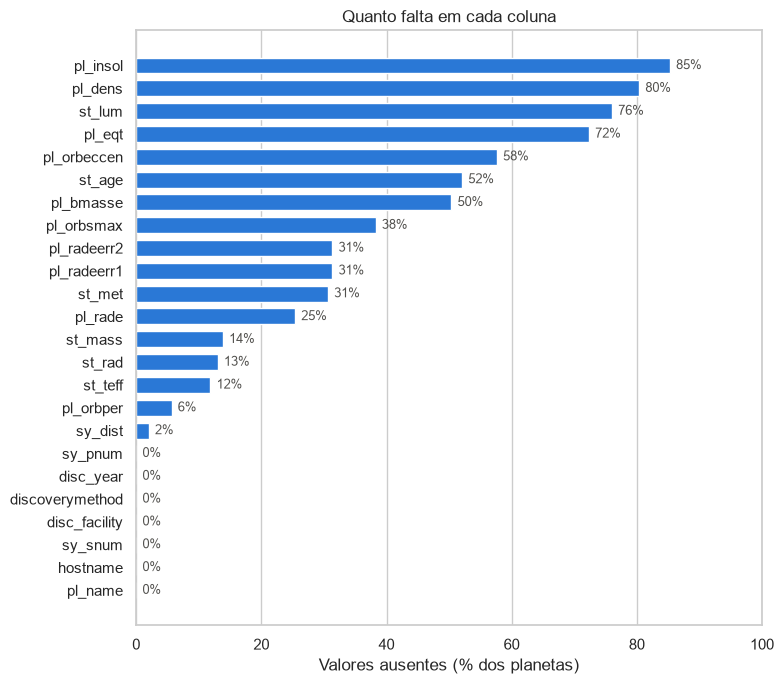

In [5]:
ausentes = (df.isna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(ausentes.index, ausentes.values, color=AZUL, height=0.7)
for y, valor in enumerate(ausentes.values):
    ax.text(valor + 1, y, f"{valor:.0f}%", va="center", fontsize=9, color="#52514e")
ax.set(xlim=(0, 100), xlabel="Valores ausentes (% dos planetas)", ylabel="",
       title="Quanto falta em cada coluna")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Leitura do gráfico** — dá para separar as colunas em quatro grupos:

| Grupo | Colunas | Ausentes |
|---|---|---|
| Completas | dados de descoberta (`discoverymethod`, `disc_year`, `disc_facility`), `sy_pnum`, `sy_snum`, nomes | 0% |
| Bem preenchidas | `sy_dist`, `pl_orbper`, `st_teff`, `st_rad`, `st_mass` | 2–14% |
| Pela metade | `pl_rade`, `pl_radeerr1/2`, `st_met`, `pl_orbsmax`, `pl_bmasse`, `st_age`, `pl_orbeccen` | 25–58% |
| Raras | `pl_eqt`, `st_lum`, `pl_dens`, `pl_insol` | 72–85% |

Duas consequências práticas:

- O **Módulo 1** (viés observacional) usa justamente as colunas completas — por isso é o
  ponto de entrada.
- `pl_insol` (insolação) falta em 85% dos planetas, mas as colunas da estrela e o período
  estão bem preenchidos. Dá para **calcular** a insolação com física (Módulo 2) em vez de
  jogar fora 85% da amostra.

### Os dados não faltam por acaso

Uma pergunta importante: os valores ausentes estão espalhados aleatoriamente, ou existe um
padrão? Vamos ver que fração dos planetas tem **raio** (`pl_rade`) e **massa** (`pl_bmasse`)
medidos, separando por método de descoberta.

In [6]:
cobertura = (
    df.groupby("discoverymethod")[["pl_rade", "pl_bmasse", "pl_orbper"]]
    .apply(lambda grupo: grupo.notna().mean() * 100)
    .round(1)
)
cobertura["n_planetas"] = df["discoverymethod"].value_counts()
cobertura.sort_values("n_planetas", ascending=False)

,pl_rade,pl_bmasse,pl_orbper,n_planetas
discoverymethod,,,,
Transit,99.500,32.100,99.900,4688
Radial Velocity,2.600,99.700,99.800,1200
Microlensing,0.000,100.000,3.900,283
Imaging,31.600,95.900,22.400,98
Transit Timing Variations,26.200,88.100,100.000,42
Eclipse Timing Variations,0.000,100.000,100.000,17
Orbital Brightness Modulation,33.300,66.700,100.000,9
Pulsar Timing,0.000,100.000,87.500,8
Astrometry,0.000,100.000,100.000,6


**Existe um padrão fortíssimo:**

- Planetas descobertos por **trânsito** têm raio em 99,5% dos casos, mas massa em só ~32%.
- Planetas descobertos por **velocidade radial** têm massa em 99,7% dos casos, mas raio em só ~3%.

Isso faz sentido físico. O trânsito mede a *sombra* do planeta passando na frente da estrela
→ dá o **tamanho**. A velocidade radial mede o *bamboleio* da estrela puxada pela gravidade do
planeta → dá a **massa**. Cada método "enxerga" uma propriedade diferente.

> ⚠️ **Lição para todo o projeto:** se filtrarmos "só planetas com raio", eliminamos quase
> todos os planetas de velocidade radial — sem perceber, estaríamos mudando a amostra. É por
> isso que nesta EDA **não** aplicamos o `limpar_dados()` de `src/preprocessing.py` (ele remove
> quem não tem raio). Cada módulo decide seu próprio filtro, sabendo o que está deixando de fora.

In [7]:
# Algum planeta aparece mais de uma vez?
print(f"Nomes de planeta repetidos: {df['pl_name'].duplicated().sum()}")

Nomes de planeta repetidos: 0


Nenhum repetido: o `data_fetch.py` já baixa só a linha "oficial" de cada planeta
(`default_flag = 1`).

## 3. Estatística descritiva

O `describe()` resume cada coluna numérica: contagem, média, desvio padrão, mínimo, quartis e
máximo. Um truque útil é **comparar a média (`mean`) com a mediana (`50%`)**: quando elas são
muito diferentes, a distribuição é assimétrica (tem valores extremos puxando a média).

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,5995.000,4336.823,160686.230,0.091,4.307,10.713,38.428,8040000.000
pl_orbsmax,3923.000,20.135,405.174,0.004,0.053,0.116,0.830,19000.000
pl_orbeccen,2692.000,0.150,0.184,0.000,0.009,0.081,0.211,0.950
pl_insol,936.000,376.948,806.920,0.002,9.595,61.500,382.170,9110.000
pl_eqt,1757.000,1001.618,540.226,50.000,574.000,900.000,1375.000,3921.000
pl_rade,4742.000,4.502,4.948,0.310,1.640,2.468,4.197,87.206
pl_bmasse,3154.000,770.714,1503.990,0.020,12.150,171.550,699.217,9534.852
pl_dens,1248.000,5.470,59.002,0.030,0.560,1.524,3.700,2000.000
pl_radeerr1,4363.000,0.510,1.467,0.000,0.124,0.270,0.550,68.910
pl_radeerr2,4363.000,-0.410,0.914,-32.506,-0.450,-0.220,-0.110,0.000


**O que chama atenção:**

- `pl_orbper`: a média é ~4.300 dias, mas a **mediana é ~11 dias**. Metade dos planetas dá
  uma volta na estrela em menos de 11 dias (Mercúrio leva 88!). Alguns poucos planetas com
  períodos gigantescos puxam a média para cima.
- `pl_bmasse`: mediana ~170 massas terrestres, média ~770. Mesma história.
- `pl_rade`: mediana ~2,5 raios terrestres — o planeta "típico" do catálogo é maior que a
  Terra e menor que Netuno (≈ 3,9). Não existe nada assim no Sistema Solar.
- `disc_year`: a mediana é 2016 — metade de todos os planetas foi descoberta de 2016 para cá.

Quando a média engana desse jeito, **a mediana é a medida mais honesta**, e gráficos em
**escala logarítmica** ficam muito mais legíveis (seção 6).

Os máximos também parecem estranhos em algumas colunas — `pl_dens` = 2000 g/cm³,
`st_teff` = 40.000 K, `pl_orbper` = 8 milhões de dias. Vamos olhar de perto.

## 4. Valores estranhos (outliers)

Um valor extremo pode ser um **erro** ou um **objeto realmente incomum**. Não dá para decidir
só olhando o número: é preciso olhar a linha inteira e pensar na física.

In [9]:
colunas = ["pl_name", "discoverymethod", "pl_rade", "pl_bmasse", "pl_dens"]
df.nlargest(5, "pl_dens")[colunas]

,pl_name,discoverymethod,pl_rade,pl_bmasse,pl_dens
6282,KOI-2513.01,Transit,2.802,7310.053,2000.000
5746,Kepler-391 c,Transit,2.880,450.000,400.000
4434,Kepler-391 b,Transit,2.500,1100.000,380.000
3736,Kepler-37 b,Transit,0.310,0.790,140.000
5678,Kepler-131 c,Transit,0.840,8.250,77.700


O material mais denso da Terra (ósmio) tem ~22,6 g/cm³, e a própria Terra tem 5,5 g/cm³.
Um planeta com **2000 g/cm³** é fisicamente impossível: provavelmente a massa é só um
*limite superior* ou o raio está subestimado. Isso importa no **Módulo 3** (composição), que
usa densidade — lá esses casos precisam ser tratados.

In [10]:
colunas = ["pl_name", "discoverymethod", "st_teff", "st_rad", "st_mass"]
pd.concat([df.nlargest(3, "st_teff"), df.nsmallest(3, "st_teff")])[colunas]

,pl_name,discoverymethod,st_teff,st_rad,st_mass
2749,NSVS 14256825 b,Eclipse Timing Variations,40000.000,0.188,0.419
73,NY Vir c,Eclipse Timing Variations,32780.000,0.151,0.459
3628,NY Vir b,Eclipse Timing Variations,32780.000,0.151,0.459
3470,WISE J033605.05-014350.4 b,Imaging,415.000,NaN,0.013
2422,WISEP J121756.91+162640.2 A b,Imaging,575.000,0.091,0.029
6310,CFBDSIR J145829+101343 b,Imaging,580.500,NaN,0.021


Aqui os extremos são **reais**, não erros:

- As estrelas de ~30.000–40.000 K são **pequenas e muito quentes** (raio ~0,15–0,2 do Sol):
  estrelas em fase final de vida, em sistemas binários que eclipsam. Os planetas foram achados
  por *variação no tempo dos eclipses*.
- As "estrelas" de ~400–600 K são **anãs marrons** — objetos entre planeta e estrela, frios
  demais para brilhar como uma estrela normal. Os planetas foram fotografados diretamente
  (*Imaging*).

In [11]:
colunas = ["pl_name", "discoverymethod", "pl_orbper", "pl_orbsmax"]
maiores = df.nlargest(5, "pl_orbper")[colunas].copy()
maiores["periodo_em_anos"] = maiores["pl_orbper"] / 365.25
maiores

,pl_name,discoverymethod,pl_orbper,pl_orbsmax,periodo_em_anos
2418,CFHTWIR-Oph 98 b,Imaging,8040000.000,200.000,22012.320
6190,Oph 11 b,Imaging,7300000.000,243.000,19986.311
2146,VHS J125601.92-125723.9 b,Imaging,5800000.000,350.000,15879.535
1438,b Cen AB b,Imaging,1790000.000,556.000,4900.753
2299,HR 8799 b,Imaging,170000.000,68.000,465.435


Planetas com períodos de **centenas a dezenas de milhares de anos**, a dezenas ou centenas de
UA da estrela (Netuno fica a 30 UA do Sol).
Também são reais: são planetas gigantes jovens e muito afastados, e por isso dá para
**fotografá-los** separados da estrela (*Imaging*). O período, nesses casos, é estimado — ninguém
observou uma volta completa.

**Conclusão da seção:** não removemos outliers automaticamente. Cada módulo decide o que fazer
com base na sua pergunta (o 2000 g/cm³ é problema no Módulo 3; as anãs marrons talvez sejam no
Módulo 4).

## 5. Variáveis de descoberta

Estas são as colunas 100% preenchidas: **como**, **quando** e **por quem** cada planeta foi
descoberto. Aqui damos só uma primeira olhada — o aprofundamento é o trabalho das duplas do
Módulo 1.

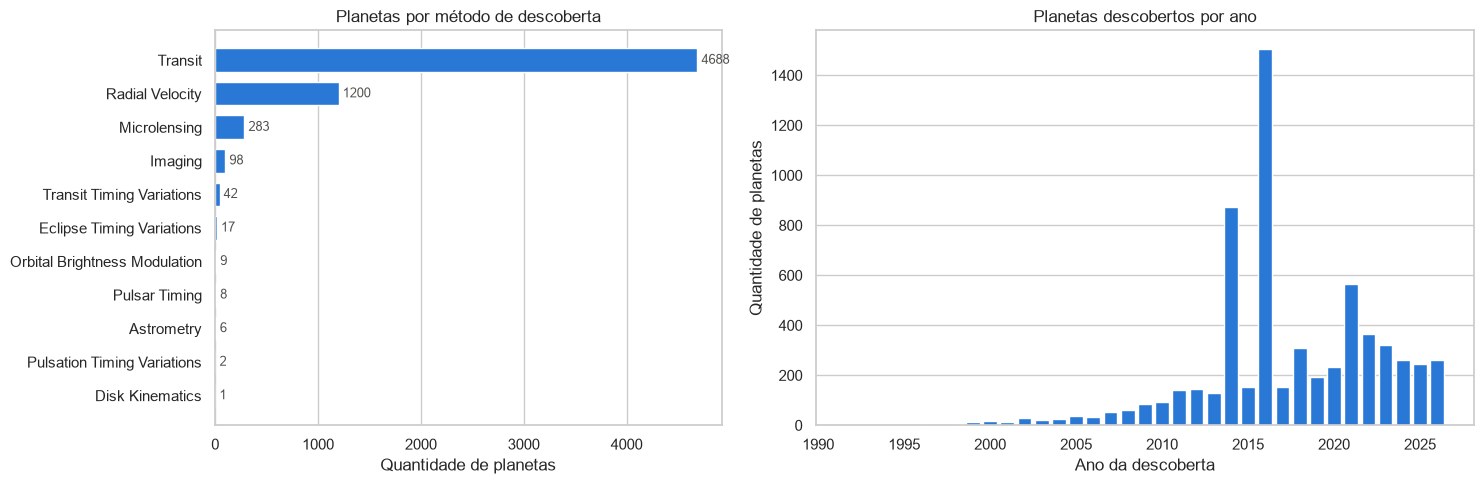

In [12]:
metodos = df["discoverymethod"].value_counts().sort_values()
anos = df["disc_year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.3]})

axes[0].barh(metodos.index, metodos.values, color=AZUL, height=0.7)
for y, valor in enumerate(metodos.values):
    axes[0].text(valor + 40, y, str(valor), va="center", fontsize=9, color="#52514e")
axes[0].set(title="Planetas por método de descoberta", xlabel="Quantidade de planetas", ylabel="")
axes[0].grid(axis="y", visible=False)

axes[1].bar(anos.index, anos.values, color=AZUL, width=0.8)
axes[1].set(title="Planetas descobertos por ano", xlabel="Ano da descoberta",
            ylabel="Quantidade de planetas")
axes[1].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

In [13]:
# Os 10 observatórios/missões que mais descobriram planetas
df["disc_facility"].value_counts().head(10)

disc_facility
Kepler                                          2787
Transiting Exoplanet Survey Satellite (TESS)     929
K2                                               549
Multiple Observatories                           355
La Silla Observatory                             310
W. M. Keck Observatory                           193
KMTNet                                           139
SuperWASP                                        122
OGLE                                             111
HATSouth                                          73
Name: count, dtype: int64

**Primeiras impressões (e perguntas para o Módulo 1):**

- **Trânsito domina** (~74% do catálogo), seguido de velocidade radial (~19%). Os outros nove
  métodos juntos somam ~7%.
- As descobertas crescem a partir de ~2010 e há **dois picos isolados**: 2014 (~870 planetas)
  e, maior ainda, 2016 (~1.500 — 10× os anos vizinhos). *O que aconteceu nesses anos?* →
  pergunta da Dupla 1.
- A missão **Kepler** sozinha responde por ~44% de todos os planetas conhecidos. Somando TESS
  e K2 (a segunda fase do Kepler), três missões espaciais de trânsito descobriram ~67% do
  catálogo. → pergunta da Dupla 4.

Se quase tudo foi descoberto por *um* método e por *poucos* telescópios, o catálogo carrega as
preferências desses instrumentos. Guardem essa ideia.

## 6. Distribuições das variáveis numéricas

Vamos ver como os valores se espalham, usando a função `plot_distribuicoes` de
`src/visualization.py`. Primeiro em escala normal, depois em escala logarítmica.

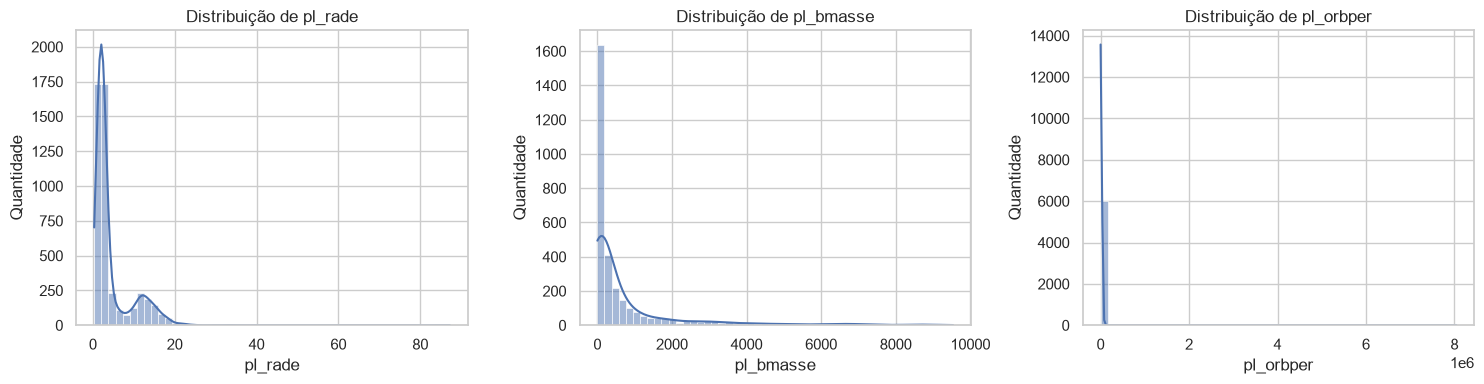

In [14]:
viz.plot_distribuicoes(df, ["pl_rade", "pl_bmasse", "pl_orbper"], bins=50, log=False)
plt.show()

Em escala normal os gráficos são quase inúteis: tudo se amontoa numa barra perto do zero e
uma cauda longuíssima estica o eixo. Isso acontece porque os valores variam por **muitas
ordens de grandeza** (períodos de horas até milhares de anos).

A solução é a **escala logarítmica**: no `log10`, cada unidade do eixo é um fator 10
(1 = 10, 2 = 100, 3 = 1000...).

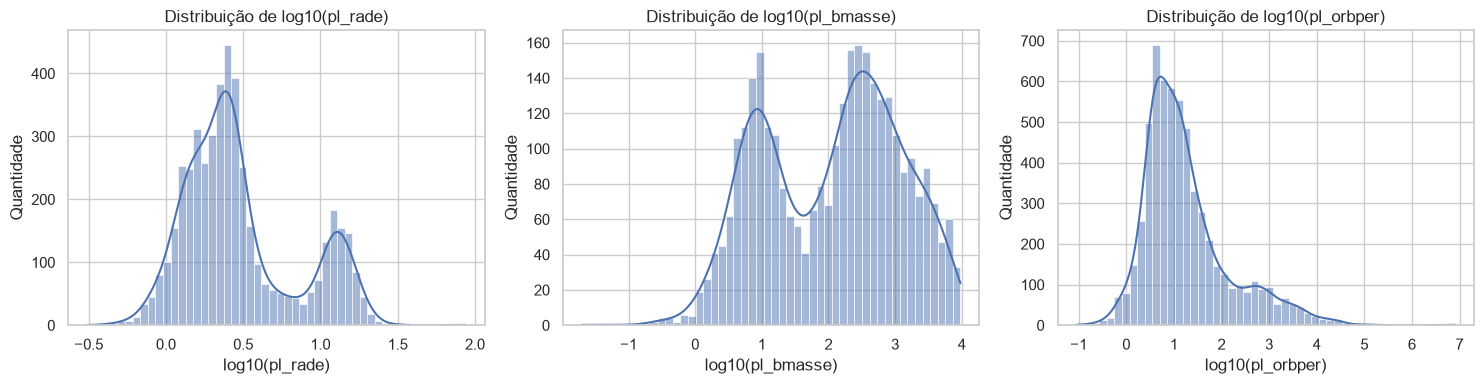

In [15]:
viz.plot_distribuicoes(df, ["pl_rade", "pl_bmasse", "pl_orbper"], bins=50, log=True)
plt.show()

**Agora sim dá para ler:**

- **Raio** (`log10` ≈ 0,3–0,5 → 2–3 raios terrestres): a grande maioria dos planetas é
  pequena, entre super-Terras e mini-Netunos. Há um segundo grupo menor perto de `log10` ≈ 1,1
  (~13 raios terrestres ≈ tamanho de Júpiter): os gigantes gasosos.
- **Massa**: também aparecem dois grupos — um de planetas de poucas massas terrestres e outro,
  maior, perto de `log10` ≈ 2,5 (~300 massas terrestres ≈ Júpiter). Lembrem que massa vem
  quase só de velocidade radial, que é mais sensível a planetas pesados.
- **Período**: pico entre `log10` ≈ 0,5 e 1 (3 a 10 dias). A enorme maioria dos planetas
  conhecidos orbita **muito perto** da estrela. Há uma "corcova" menor perto de `log10` ≈ 2,5–3
  (1 a 3 anos), formada principalmente por planetas de velocidade radial.

Reparem que raio e massa contam histórias diferentes sobre qual planeta é "comum" — porque
cada um vem de um método diferente (seção 2). Isso é o Módulo 1 aparecendo de novo.

Estrelas acima de 10.000 K fora do gráfico de temperatura: 20


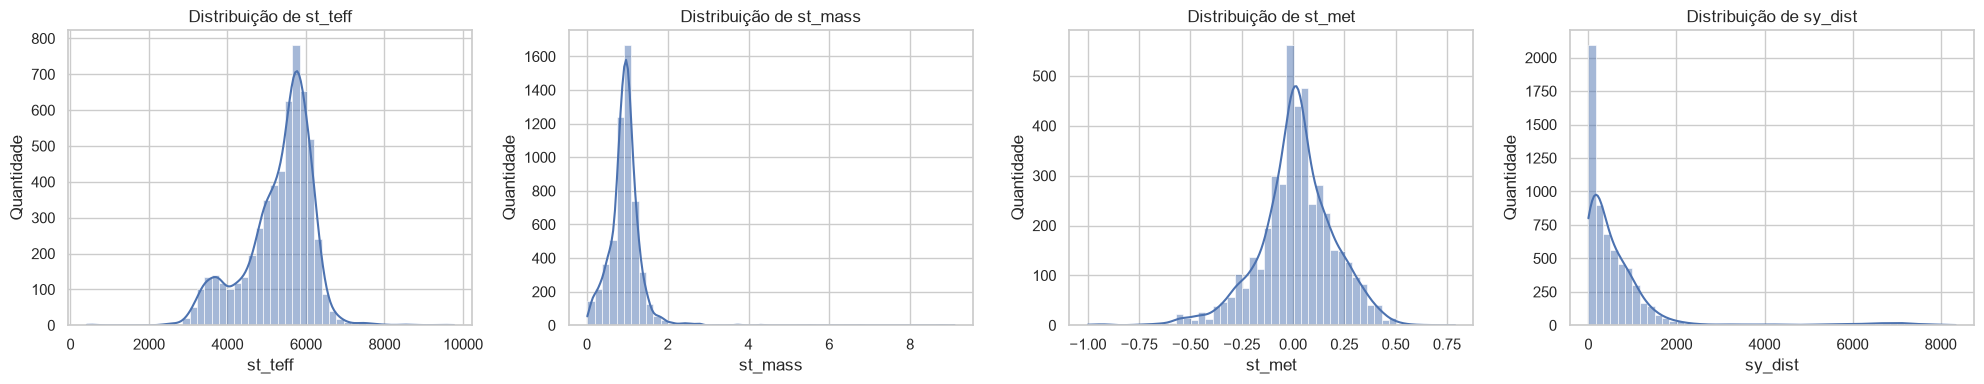

In [16]:
# Agora as propriedades das estrelas e a distância até o sistema
# Só para visualizar, escondemos as poucas estrelas acima de 10.000 K (seção 4): elas esticariam
# o eixo até 40.000 K e esmagariam o resto. O .where() troca esses valores por NaN apenas
# na coluna st_teff — as outras colunas continuam intactas.
quentes = (df["st_teff"] >= 10000).sum()
print(f"Estrelas acima de 10.000 K fora do gráfico de temperatura: {quentes}")

df_estrelas = df.assign(st_teff=df["st_teff"].where(df["st_teff"] < 10000))
viz.plot_distribuicoes(df_estrelas, ["st_teff", "st_mass", "st_met", "sy_dist"], bins=50, log=False)
plt.show()

- **Temperatura da estrela**: pico em ~5.500–6.000 K, bem perto do Sol (5.772 K). A maioria
  das estrelas com planetas conhecidos é parecida com o Sol — em parte porque as missões
  escolheram observar estrelas assim.
- **Massa da estrela**: concentrada perto de 1 massa solar, pelo mesmo motivo.
- **Metalicidade** (`st_met`): centrada em ~0 (igual ao Sol), levemente puxada para valores
  positivos. O Módulo 4 investiga se estrelas mais ricas em metais têm mais planetas gigantes.
- **Distância**: 75% dos sistemas estão a menos de ~820 parsecs, mas há um pequeno grupo
  isolado entre 6.000 e 8.000 parsecs (perto do centro da galáxia): são os planetas de
  **microlente gravitacional**, cuja distância mediana é ~6.200 pc.

## 7. Relações entre variáveis

Agora olhamos duas variáveis ao mesmo tempo. A cor de cada ponto mostra o **método de
descoberta** (trânsito, velocidade radial ou outros), para ver se os métodos ocupam regiões
diferentes dos gráficos. Os dois eixos estão em escala log.

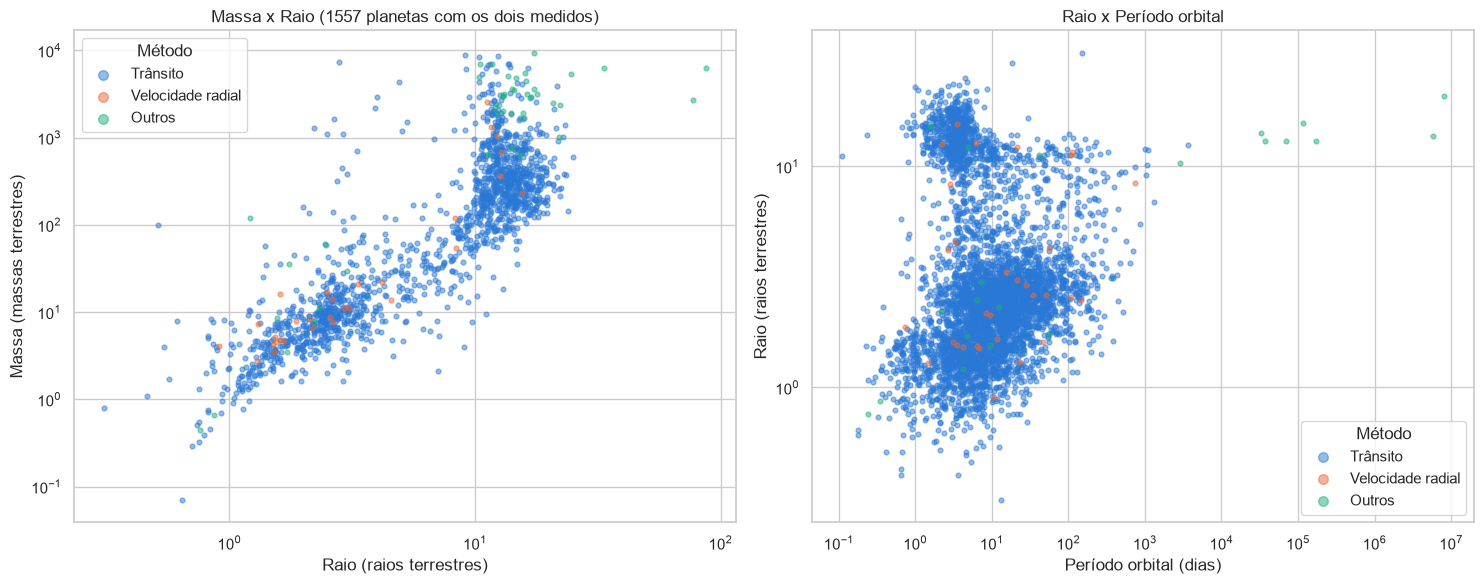

In [17]:
# Agrupa os métodos: os dois principais + "Outros"
df["metodo"] = df["discoverymethod"].map(
    {"Transit": "Trânsito", "Radial Velocity": "Velocidade radial"}
).fillna("Outros")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for metodo, cor in CORES_METODO.items():
    parte = df[df["metodo"] == metodo]
    axes[0].scatter(parte["pl_rade"], parte["pl_bmasse"], s=12, alpha=0.5, color=cor, label=metodo)
    axes[1].scatter(parte["pl_orbper"], parte["pl_rade"], s=12, alpha=0.5, color=cor, label=metodo)

n_massa_raio = df[["pl_rade", "pl_bmasse"]].dropna().shape[0]
axes[0].set(xscale="log", yscale="log", xlabel="Raio (raios terrestres)",
            ylabel="Massa (massas terrestres)",
            title=f"Massa x Raio ({n_massa_raio} planetas com os dois medidos)")
axes[1].set(xscale="log", yscale="log", xlabel="Período orbital (dias)",
            ylabel="Raio (raios terrestres)", title="Raio x Período orbital")

for ax in axes:
    ax.legend(title="Método", markerscale=2)

plt.tight_layout()
plt.show()

**Massa x Raio (esquerda):** planetas maiores são mais massivos — até uns ~10–15 raios
terrestres. Depois disso o raio **para de crescer** mesmo com a massa aumentando muito: é o
comportamento dos gigantes gasosos (colocar mais gás comprime o planeta em vez de aumentá-lo).
Só ~1.600 planetas aparecem aqui, porque é preciso ter raio *e* massa — tipicamente, planetas
de trânsito que depois foram medidos por velocidade radial.

**Raio x Período (direita):** quase todos os pontos são **azuis** (trânsito) e ficam do lado
esquerdo (períodos curtos). Velocidade radial quase não aparece porque, como vimos, esses
planetas quase nunca têm raio. E o canto de **planetas pequenos com período longo** (tipo a
Terra: 1 raio, 365 dias) está praticamente vazio. Planetas assim não existem — ou são só
difíceis de detectar? → essa é exatamente a pergunta central do Módulo 1.

### Mapa de correlações

Para ter uma visão geral de quais variáveis "andam juntas", calculamos a correlação entre
todos os pares. Usamos a **correlação de Spearman**, que compara a *ordem* dos valores em vez
dos valores em si — por isso ela não é enganada por valores extremos nem precisa de escala log.

- **+1**: quando uma sobe, a outra sempre sobe · **−1**: quando uma sobe, a outra sempre desce
- **0**: sem relação (em ordem)

⚠️ Correlação **não** é causa. E cada par é calculado só com os planetas que têm as duas
colunas preenchidas, então cada número usa uma amostra diferente.

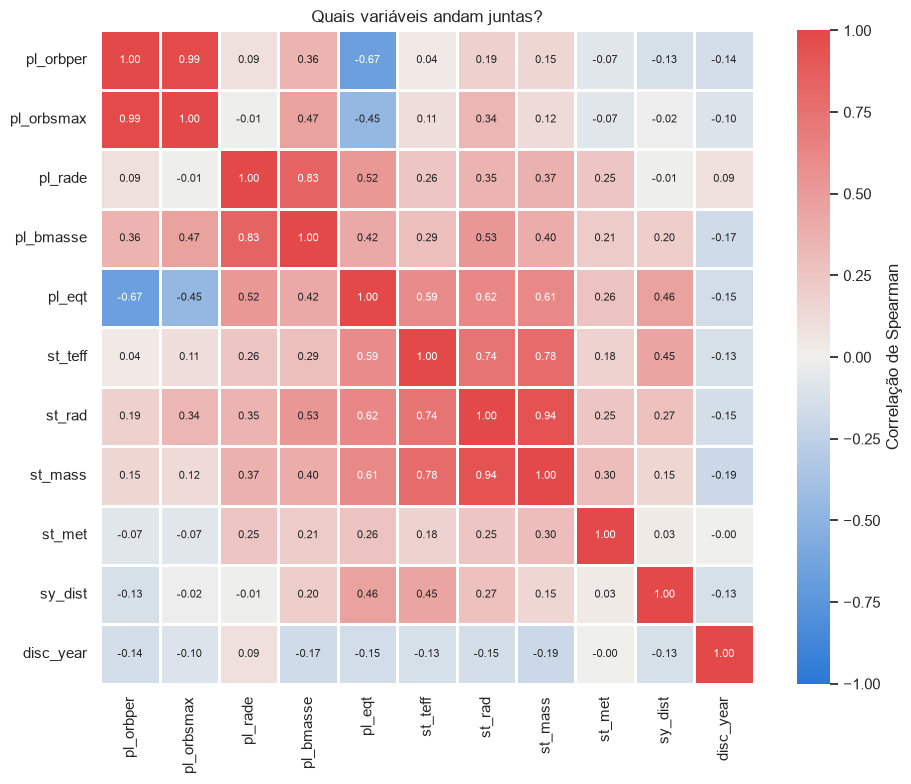

In [18]:
from matplotlib.colors import LinearSegmentedColormap

colunas = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_eqt",
           "st_teff", "st_rad", "st_mass", "st_met", "sy_dist", "disc_year"]
correlacao = df[colunas].corr(method="spearman")

# Azul = correlação negativa, cinza = nenhuma, vermelho = positiva
azul_cinza_vermelho = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlacao, vmin=-1, vmax=1, cmap=azul_cinza_vermelho, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=1, linecolor="white", square=True,
            cbar_kws={"label": "Correlação de Spearman"}, ax=ax)
ax.set_title("Quais variáveis andam juntas?")
plt.tight_layout()
plt.show()

**Destaques** (confiram os números no mapa):

- **`pl_orbper` × `pl_orbsmax` = 0,99**: quanto mais longe da estrela, mais longa a volta. É a
  **3ª lei de Kepler** aparecendo nos dados — e ela é a base dos cálculos do Módulo 2.
- **`st_rad` × `st_mass` = 0,94** e ambas ~0,75 com `st_teff`: estrelas mais massivas são
  maiores e mais quentes (física estelar).
- **`pl_eqt`** (temperatura do planeta) é **−0,67** com o período (quem está mais longe da
  estrela é mais frio) e **+0,59** com a temperatura da estrela (estrela mais quente, planeta
  mais quente). É a única correlação negativa forte do mapa.
- **`pl_rade` × `pl_bmasse` = 0,83**: a relação massa-raio da seção anterior.
- **`st_met`** tem correlação fraca e positiva com raio e massa do planeta (~0,2): um primeiro
  sinal do que o Módulo 4 vai investigar com cuidado.
- **`disc_year`** só tem correlações fracas, mas a mais forte com planetas é com a massa
  (**−0,17**): planetas descobertos mais recentemente tendem a ser **mais leves**. Isso não é
  física — os planetas não mudaram — e sim tecnologia: os instrumentos ficaram sensíveis a
  planetas menores. É o Módulo 1 de novo.

## 8. Conclusões

1. **O catálogo tem 6.354 planetas e 24 colunas**, sem nomes repetidos. As colunas de
   descoberta estão completas; as de temperatura/insolação/densidade do planeta são raras.
2. **Os dados ausentes seguem um padrão**: trânsito dá o raio, velocidade radial dá a massa.
   Filtrar por uma coluna muda silenciosamente quais planetas ficam na análise.
3. **As distribuições são muito assimétricas** — use mediana em vez de média e escala log nos
   gráficos.
4. **Alguns outliers são erros** (densidade de 2000 g/cm³) e **outros são objetos reais e
   incomuns** (anãs marrons, estrelas mortas, planetas a milhares de UA). Não se remove nada
   no automático.
5. **O planeta "típico" do catálogo** tem 2–3 raios terrestres, orbita uma estrela parecida
   com o Sol em ~10 dias e foi descoberto por trânsito — muito diferente do Sistema Solar.

### Perguntas que a EDA levantou (e onde elas serão respondidas)

| Pergunta | Módulo |
|---|---|
| O canto "planeta pequeno + período longo" está vazio porque esses planetas são raros ou porque são difíceis de ver? O que houve em 2016? | 1 — Viés observacional |
| Dá para calcular a insolação que falta em 85% dos planetas? | 2 — Habitabilidade |
| Existe um "buraco" nos tamanhos de planeta? O que fazer com densidades impossíveis? | 3 — Composição |
| Estrelas mais ricas em metais têm mais gigantes? | 4 — Estrelas hospedeiras |